In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report


In [3]:
np.random.seed(42)

In [4]:
df = pd.read_csv("atp_matches_2010_2024_missing_handled.csv")


Test Accuracy: 93.68%

              precision    recall  f1-score   support

Player B Win       0.93      0.94      0.94      6009
Player A Win       0.94      0.93      0.94      6009

    accuracy                           0.94     12018
   macro avg       0.94      0.94      0.94     12018
weighted avg       0.94      0.94      0.94     12018



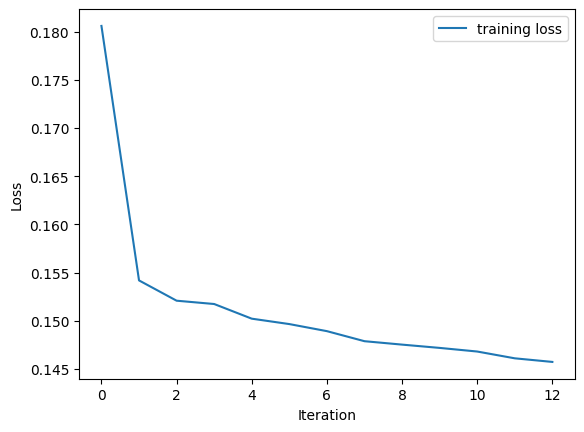

In [5]:

df["rank_diff"]    = df["winner_rank"] - df["loser_rank"]
df["ace_diff"]     = df["w_ace"]        - df["l_ace"]
df["df_diff"]      = df["w_df"]         - df["l_df"]
df["svpt_diff"]    = df["w_svpt"]       - df["l_svpt"]
df["1stIn_diff"]   = df["w_1stIn"]      - df["l_1stIn"]
df["1stWon_diff"]  = df["w_1stWon"]     - df["l_1stWon"]
df["2ndWon_diff"]  = df["w_2ndWon"]     - df["l_2ndWon"]
df["SvGms_diff"]   = df["w_SvGms"]      - df["l_SvGms"]
df["bpSaved_diff"] = df["w_bpSaved"]    - df["l_bpSaved"]
df["bpFaced_diff"] = df["w_bpFaced"]    - df["l_bpFaced"]
df["age_diff"]     = df["winner_age"]   - df["loser_age"]

df = pd.get_dummies(df, columns=["surface"], drop_first=True)


df["target"] = 1
flip_cols = [
    "rank_diff","ace_diff","df_diff","svpt_diff","1stIn_diff",
    "1stWon_diff","2ndWon_diff","SvGms_diff","bpSaved_diff","bpFaced_diff","age_diff"
]
df_flipped = df.copy()
df_flipped[flip_cols] = -df_flipped[flip_cols]
df_flipped["target"]  = 0
df = pd.concat([df, df_flipped], ignore_index=True)


df["tourney_date"] = pd.to_datetime(df["tourney_date"], format="%Y%m%d", errors="coerce")
df = df.dropna(subset=["tourney_date"])
train = df[df["tourney_date"].dt.year <= 2022]
test  = df[df["tourney_date"].dt.year >  2022]


feature_cols = [
    "ace_diff","df_diff","1stIn_diff","SvGms_diff","age_diff",
    "1stWon_diff","2ndWon_diff","bpSaved_diff","bpFaced_diff","svpt_diff",
    "rank_diff","surface_Grass","surface_Hard"
]
X_train = train[feature_cols].values
y_train = train["target"].values
X_test  = test[feature_cols].values
y_test  = test["target"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=32,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)
history = mlp.fit(X_train_scaled, y_train)


y_pred = mlp.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.2%}\n")
print(classification_report(
    y_test, y_pred,
    target_names=["Player B Win", "Player A Win"]
))

## 8. Plotting the training loss curve 
plt.plot(mlp.loss_curve_, label='training loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()